# From View to Verified Trade — A Decision Workflow with fxbt2

This notebook walks through the process of turning a **trading hypothesis** into a
**statistically tested, sized position**.

The key question answered here is: *given price (and optionally macro) data, how do
I decide whether to buy or sell, and how much confidence should I place in that signal?*

### Structure
| Section | What you learn |
|---|---|
| 1 — Setup | Imports, synthetic data, helper utilities |
| 2 — Reading a signal | What +1 / -1 / 0 mean; how to visualise signal vs price |
| 3 — Single hypothesis test | Take a view, translate to signal, run backtest |
| 4 — Signal diagnostics | Is the edge real? Hit rate, autocorrelation, regime analysis |
| 5 — Combining signals | Blend trend + carry + mean-reversion for robustness |
| 6 — Signal vs signal | Which works best for each pair? |
| 7 — Adding filters | Vol regime and session filters to reduce noise |
| 8 — Conviction sizing | Scale position size by signal strength |
| 9 — Walk-forward reality check | Does the edge survive unseen data? |
| 10 — Final trade decision | Synthesise everything into a go / no-go framework |

---

> **Synthetic data note:** All prices are randomly generated. The point is the *methodology*,
> not the specific results. Replace `prices` with your real data and the entire workflow applies.


## 1 — Setup

In [29]:
import sys
sys.path.insert(0, "/Users/joshua.choy/Desktop/codebases/fx_projects/venv/lib/python3.11/site-packages")
sys.path.insert(1, "/Users/joshua.choy/Desktop/codebases/fx_projects")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

from fxbt2 import Backtest
from fxbt2.signals.price import (
    momentum, crossover, macd_signal, breakout,
    mean_reversion, rsi_signal, vol_regime,
)
from fxbt2.signals.macro import carry_fwd, carry_yield, yield_range, yield_trend
from fxbt2.costs.model import FixedSpreadModel
from fxbt2.backtest.positions import fixed_size, vol_target, equal_weight, inverse_vol_weight
from fxbt2.metrics.stats import compare, sharpe, hit_rate, profit_factor
from fxbt2.report.tearsheet import plot_tearsheet

print("Setup complete")

Setup complete


### Synthetic Data

Six FX pairs, 6 years of daily data (2019–2024).
We also generate synthetic implied yields so carry signals can be tested.

**You can substitute `prices` and `impl_yield` with real data from a Bloomberg loader
or a CSV — the rest of the notebook stays identical.**

In [30]:
np.random.seed(42)

dates = pd.bdate_range("2019-01-02", "2024-12-31")
n     = len(dates)

PAIR_PARAMS = {
    "EURUSD": (1.1200, 0.0060,  0.00),
    "GBPUSD": (1.2800, 0.0080,  0.01),
    "USDJPY": (109.00, 0.6500,  0.03),
    "AUDUSD": (0.7200, 0.0065, -0.01),
    "USDMXN": (19.50,  0.1800,  0.02),
    "USDZAR": (14.80,  0.2200,  0.04),
}

price_data = {}
for pair, (s0, dv, drift) in PAIR_PARAMS.items():
    log_ret = np.random.normal(drift / 252, dv / s0, n)
    price_data[pair] = s0 * np.exp(np.cumsum(log_ret))

prices = pd.DataFrame(price_data, index=dates)
prices.index.name = "date"
PAIRS = list(prices.columns)

# Synthetic implied yields (annualised rate differential, base vs quote)
YIELD_PARAMS = {
    "EURUSD": (-0.010, 0.004),  # EUR carries lower yield than USD
    "GBPUSD": ( 0.005, 0.003),
    "USDJPY": ( 0.030, 0.005),  # USD carries much higher yield than JPY
    "AUDUSD": (-0.005, 0.004),
    "USDMXN": ( 0.060, 0.012),  # MXN high-yield EM
    "USDZAR": ( 0.050, 0.010),  # ZAR high-yield EM
}
yield_data = {}
for pair, (mean, std) in YIELD_PARAMS.items():
    yd = np.zeros(n)
    yd[0] = mean
    for t in range(1, n):
        yd[t] = 0.97 * yd[t-1] + 0.03 * mean + np.random.normal(0, std)
    yield_data[pair] = yd
impl_yield = pd.DataFrame(yield_data, index=dates)

# Synthetic forward points (consistent with yields)
pip_scale = {"EURUSD": 1e-4, "GBPUSD": 1e-4, "USDJPY": 1e-2,
             "AUDUSD": 1e-4, "USDMXN": 1e-4, "USDZAR": 1e-4}
fwd_points = pd.DataFrame({
    p: -impl_yield[p] / 12 * prices[p] / pip_scale[p]
    for p in PAIRS
}, index=dates)

print(f"{len(dates)} trading days  |  {len(PAIRS)} pairs: {PAIRS}")
prices.tail(3)

1565 trading days  |  6 pairs: ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'USDMXN', 'USDZAR']


,EURUSD,GBPUSD,USDJPY,AUDUSD,USDMXN,USDZAR
date,,,,,,
2024-12-27,1.632977,1.470319,94.429862,0.458002,16.415150,30.552633
2024-12-30,1.640729,1.471045,94.738310,0.453853,16.459522,31.027628
2024-12-31,1.647218,1.467325,94.641804,0.452480,16.607729,31.407695


---
## 2 — Reading a Signal: What +1, 0, -1 Mean

Every signal in fxbt2 outputs a DataFrame with the **same shape as your price data**.
Each cell is one of:

| Value | Meaning |
|---|---|
| `+1` | Long the base currency (e.g. buy EUR in EURUSD) |
| `-1` | Short the base currency (e.g. sell EUR in EURUSD) |
| `0` | Flat — no position |

Signals can also be **continuous** (e.g. z-scores between -3 and +3), in which case
the magnitude reflects conviction — a larger absolute value means a stronger view.

> **No-lookahead guarantee:** all signals apply `.shift(1)` internally.
> The signal on day T is computed from data available at close of day T-1,
> and is traded at the open of day T.

The chart below shows price alongside the raw signal for EURUSD:

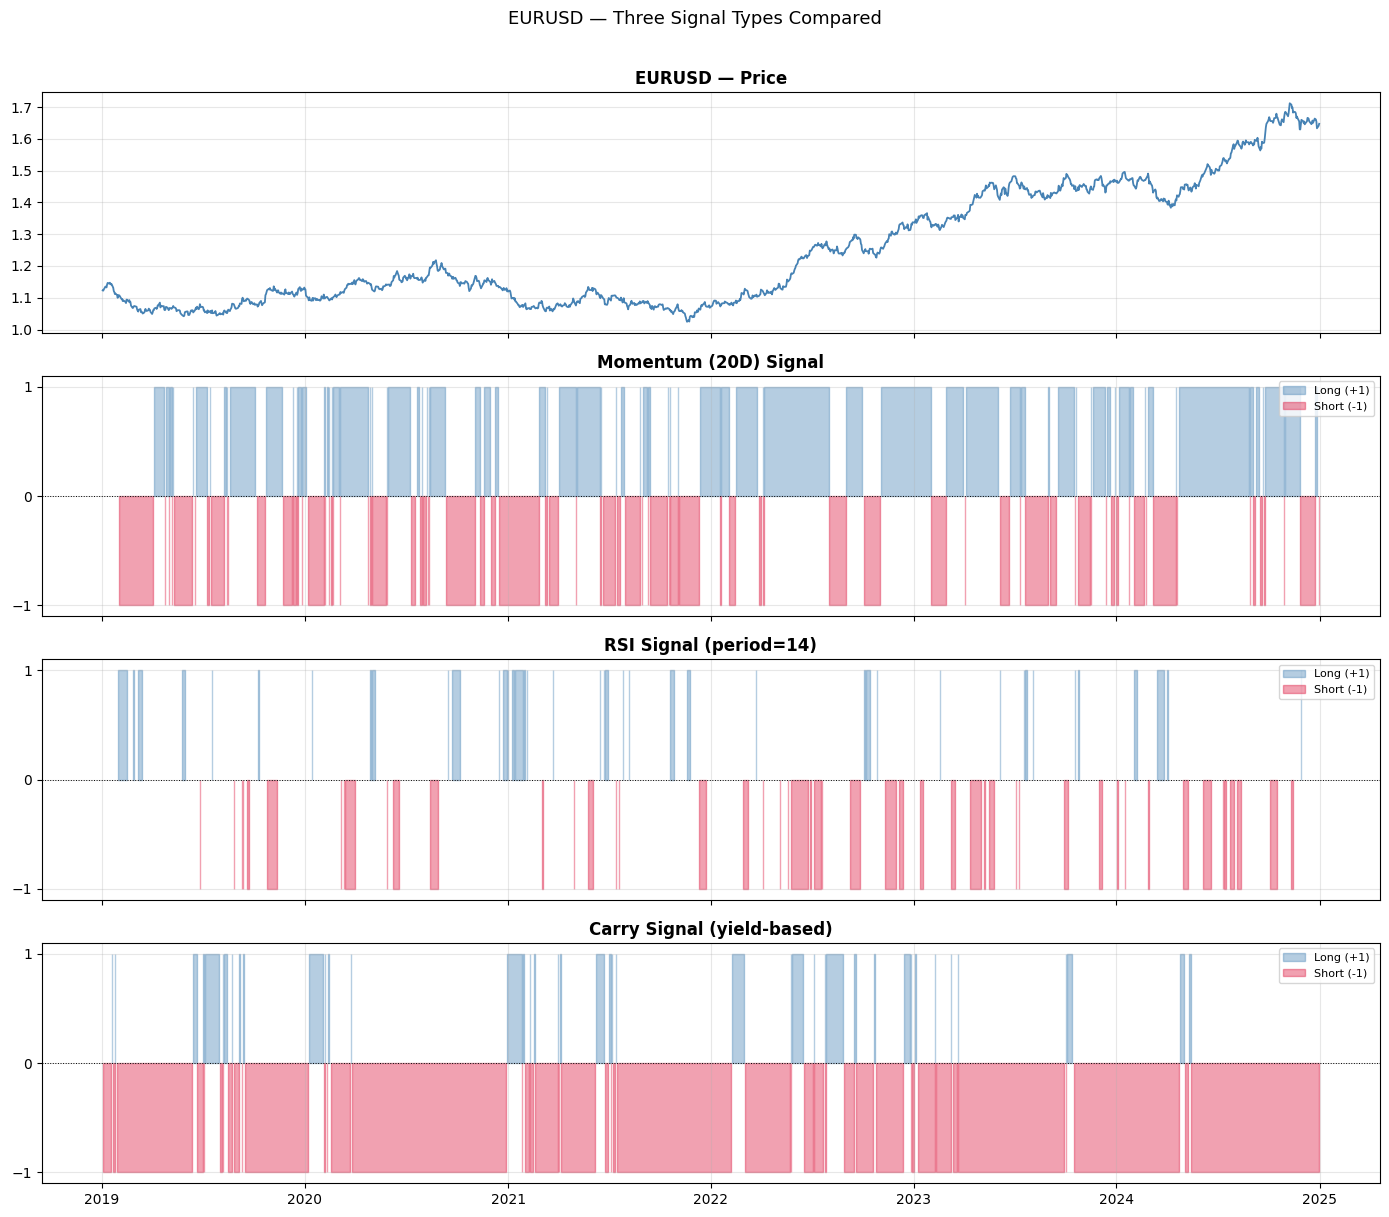

In [31]:
pair = "EURUSD"

# 20-day momentum: +1 if price today > price 20 days ago, else -1
sig_mom  = momentum(prices[[pair]], lookback=20)
# RSI mean-reversion: +1 oversold (<30), -1 overbought (>70)
sig_rsi  = rsi_signal(prices[[pair]], period=14, oversold=30, overbought=70)
# Carry: long when impl yield is positive (USD earns more), short when negative
sig_carry = carry_yield(impl_yield[[pair]], signal_type="sign")

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Price
axes[0].plot(prices.index, prices[pair], lw=1.3, color="steelblue")
axes[0].set_title(f"{pair} — Price", fontweight="bold")
axes[0].grid(True, alpha=0.3)

# Signal plots
for ax, sig, title, col in zip(
    axes[1:],
    [sig_mom, sig_rsi, sig_carry],
    ["Momentum (20D) Signal", "RSI Signal (period=14)", "Carry Signal (yield-based)"],
    ["darkorange", "purple", "green"],
):
    s = sig[pair]
    ax.fill_between(s.index, s.values, 0,
                    where=s > 0, color="steelblue", alpha=0.4, label="Long (+1)")
    ax.fill_between(s.index, s.values, 0,
                    where=s < 0, color="crimson",   alpha=0.4, label="Short (-1)")
    ax.axhline(0, color="black", lw=0.7, linestyle=":")
    ax.set_title(title, fontweight="bold")
    ax.set_yticks([-1, 0, 1])
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)

fig.suptitle(f"{pair} — Three Signal Types Compared", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Key observations to look for:**

- **Momentum** flips frequently — every time the 20-day return changes sign. This is a *trend-following* signal.
- **RSI** generates sparse signals — only fires when the pair is at an extreme. Fewer trades, but higher conviction per trade.
- **Carry** is slow-moving and structural — it reflects the interest rate differential, which changes over months/years.

A good signal should visually "lead" the price moves it is trying to capture. If the signal
and price are completely uncorrelated, there is no edge.


---
## 3 — Single Hypothesis Test

**Hypothesis:** *USDJPY trends because the US-Japan yield differential drives sustained flows.*

**Translation:** Use `yield_trend` as the primary signal — long USDJPY when the US-JP rate spread
is widening (USD gaining yield advantage), short when it is narrowing.

The workflow is always the same:
1. State the theory in plain English
2. Pick the signal that captures it
3. Run the backtest
4. Read the stats — does it match your expectation?

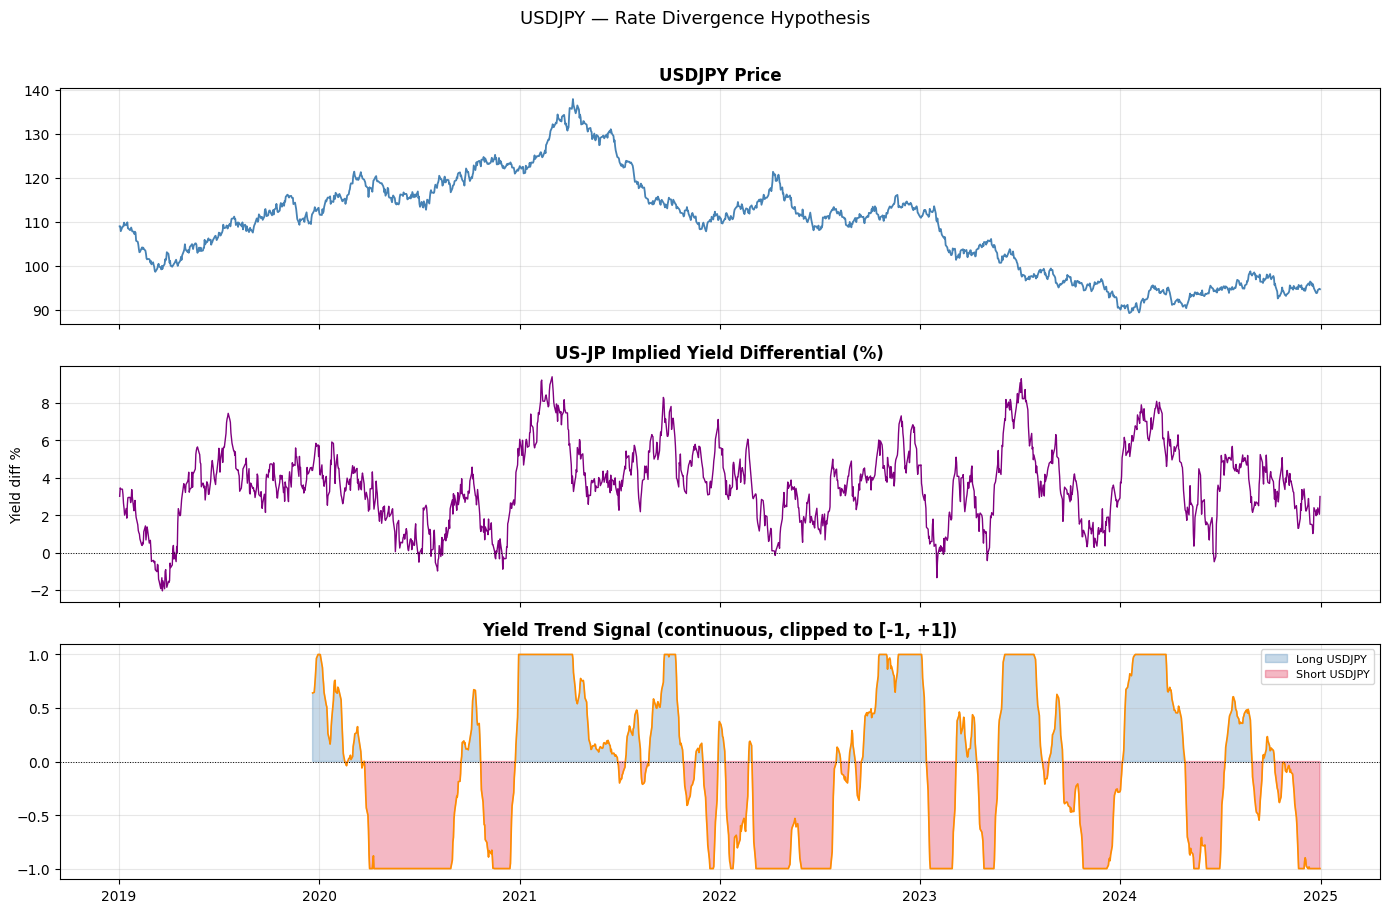

In [32]:
# --- Step 1: Build the signal for our hypothesis ---
# yield_trend: EMA-smoothed rate differential, normalised to [-1, +1]
# Long USDJPY when USD yield is rising relative to JPY (positive differential trending up)
pair = "USDJPY"

sig_hypothesis = yield_trend(impl_yield[[pair]], lookback=252, ema_span=10)

# Quick sanity check: plot signal alongside the yield differential
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(prices[pair], lw=1.3, color="steelblue")
axes[0].set_title("USDJPY Price", fontweight="bold"); axes[0].grid(True, alpha=0.3)

axes[1].plot(impl_yield[pair] * 100, lw=1, color="purple")
axes[1].axhline(0, color="black", lw=0.7, linestyle=":")
axes[1].set_title("US-JP Implied Yield Differential (%)", fontweight="bold")
axes[1].set_ylabel("Yield diff %"); axes[1].grid(True, alpha=0.3)

s = sig_hypothesis[pair]
axes[2].plot(s, lw=1.2, color="darkorange")
axes[2].axhline(0, color="black", lw=0.7, linestyle=":")
axes[2].fill_between(s.index, s.values, 0,
                     where=s > 0, color="steelblue", alpha=0.3, label="Long USDJPY")
axes[2].fill_between(s.index, s.values, 0,
                     where=s < 0, color="crimson", alpha=0.3, label="Short USDJPY")
axes[2].set_title("Yield Trend Signal (continuous, clipped to [-1, +1])", fontweight="bold")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("USDJPY — Rate Divergence Hypothesis", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

In [33]:
# --- Step 2: Run the backtest ---
bt_hyp = Backtest(
    data       = prices[[pair]],
    signals    = sig_hypothesis,
    cost_model = FixedSpreadModel(slippage_bps=0.5),
    sizer      = lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D"),
    freq       = "1D",
    name       = f"{pair} Yield Trend",
    pnl_mode   = "returns",
)
r_hyp = bt_hyp.run()
r_hyp.summary()

,USDJPY Yield Trend
Ann. Return,4.92%
Ann. Volatility,9.59%
Sharpe Ratio,0.51
Sortino Ratio,0.78
Calmar Ratio,0.23
Max Drawdown,-21.30%
Hit Rate,51.64%
Profit Factor,1.09
Avg Win/Loss,1.02
VaR (95%),-0.99%


In [34]:
# --- Step 3: Compare hypothesis signal vs naive momentum ---
r_mom = Backtest(
    data=prices[[pair]], signals=momentum(prices[[pair]], lookback=20),
    cost_model=FixedSpreadModel(slippage_bps=0.5),
    sizer=lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D"),
    freq="1D", name=f"{pair} Momentum", pnl_mode="returns",
).run()

compare(
    (r_hyp.returns, "Yield Trend (hypothesis)"),
    (r_mom.returns, "Momentum (naive)"),
    freq="1D",
)

,Yield Trend (hypothesis),Momentum (naive)
Ann. Return,4.92%,3.33%
Ann. Volatility,9.59%,10.41%
Sharpe Ratio,0.51,0.32
Sortino Ratio,0.78,0.52
Calmar Ratio,0.23,0.24
Max Drawdown,-21.30%,-14.13%
Hit Rate,51.64%,50.78%
Profit Factor,1.09,1.05
Avg Win/Loss,1.02,1.02
VaR (95%),-0.99%,-1.02%


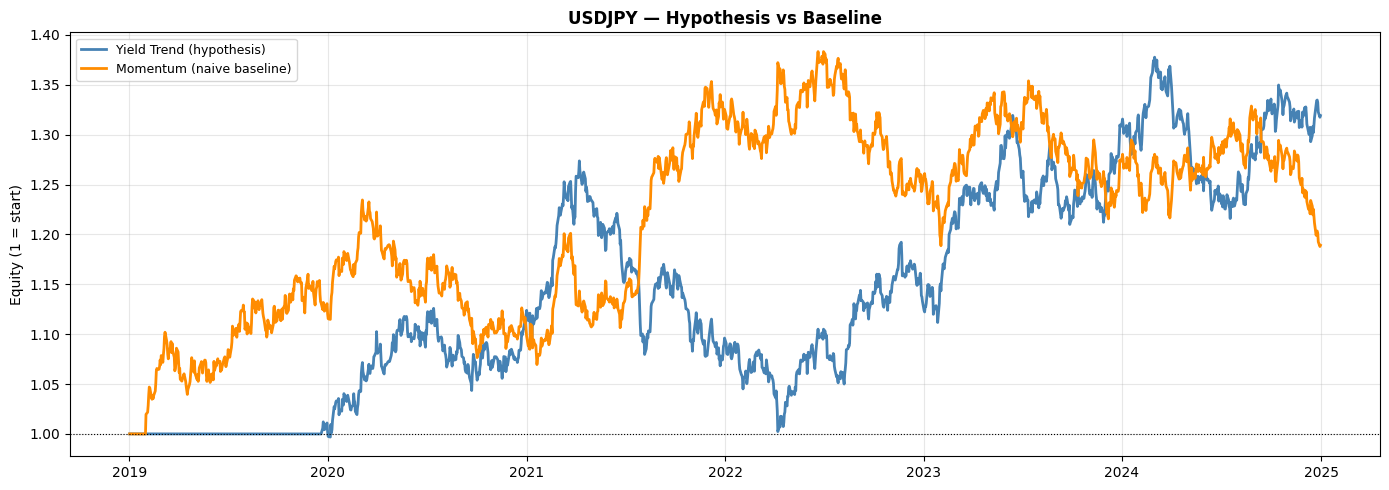

In [35]:
# --- Step 4: Visualise the equity curves side by side ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(r_hyp.equity_curve, lw=2, color="steelblue",  label="Yield Trend (hypothesis)")
ax.plot(r_mom.equity_curve, lw=2, color="darkorange", label="Momentum (naive baseline)")
ax.axhline(1, color="black", lw=0.8, linestyle=":")
ax.set_title(f"{pair} — Hypothesis vs Baseline", fontweight="bold")
ax.set_ylabel("Equity (1 = start)"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**How to interpret the results:**

- **Sharpe > 0.5**: reasonable edge, worth developing further
- **Sharpe 0 – 0.5**: marginal — look at which years it works and which it doesn't
- **Sharpe < 0**: the hypothesis is wrong in its current form — either wrong direction, wrong lookback, or wrong pair
- **Hit Rate ~50%**: common for trend signals — edge comes from *size* of winners, not frequency
- **Avg Win/Loss > 1**: the wins are bigger than the losses — this is the trend-following payoff profile


---
## 4 — Signal Diagnostics: Is the Edge Real?

Before expanding a signal to a full portfolio, run these three diagnostic checks:

| Check | What it tells you |
|---|---|
| **Annual breakdown** | Is the edge consistent year by year, or driven by 1-2 good years? |
| **Regime analysis** | Does the signal work in high-vol environments, or only in calm markets? |
| **Signal autocorrelation** | Does the signal persist (trend-like) or flip constantly (noise)? |


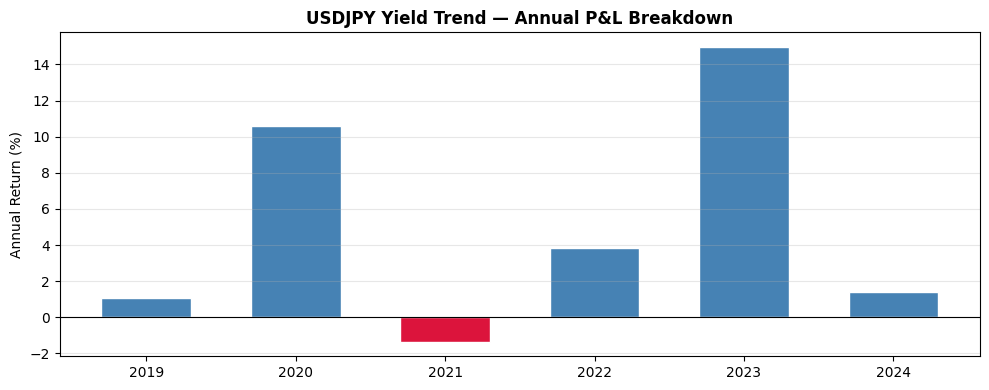

Years positive: 5 /  6
Best year:  15.0%
Worst year: -1.3%


In [36]:
# --- Annual P&L breakdown ---
ann_pnl = (
    r_hyp.returns
    .resample("A")
    .sum()
    .rename("Annual Return")
    .to_frame()
)
ann_pnl.index = ann_pnl.index.year
ann_pnl["Positive"] = ann_pnl["Annual Return"] > 0

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["steelblue" if pos else "crimson" for pos in ann_pnl["Positive"]]
ax.bar(ann_pnl.index, ann_pnl["Annual Return"] * 100, color=colors, edgecolor="white", width=0.6)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Annual Return (%)")
ax.set_title(f"{pair} Yield Trend — Annual P&L Breakdown", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print("Years positive:", ann_pnl["Positive"].sum(), "/ ", len(ann_pnl))
print("Best year: ", f"{ann_pnl['Annual Return'].max():.1%}")
print("Worst year:", f"{ann_pnl['Annual Return'].min():.1%}")

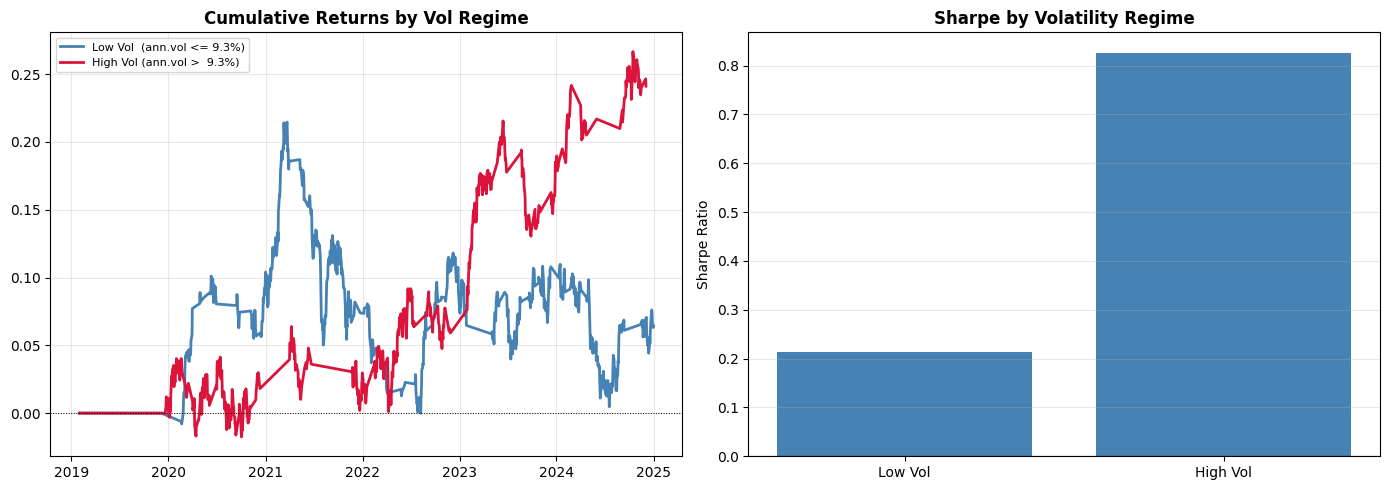

Low-vol  Sharpe: 0.21  |  773 days
High-vol Sharpe: 0.83  |  772 days


In [37]:
# --- Regime analysis: does the signal work in high vs low vol? ---
rv = prices[pair].pct_change().rolling(20).std() * np.sqrt(252)  # annualised vol
vol_median = rv.median()

returns = r_hyp.returns.dropna()
rv_aligned = rv.reindex(returns.index).ffill()

low_vol_ret  = returns[rv_aligned <= vol_median]
high_vol_ret = returns[rv_aligned >  vol_median]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Equity curves by regime
axes[0].plot(low_vol_ret.cumsum(),  lw=2, color="steelblue",  label=f"Low Vol  (ann.vol <= {vol_median:.1%})")
axes[0].plot(high_vol_ret.cumsum(), lw=2, color="crimson",    label=f"High Vol (ann.vol >  {vol_median:.1%})")
axes[0].axhline(0, color="black", lw=0.7, linestyle=":")
axes[0].set_title("Cumulative Returns by Vol Regime", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Sharpe by regime
sharpe_low  = sharpe(low_vol_ret,  freq="1D")
sharpe_high = sharpe(high_vol_ret, freq="1D")
axes[1].bar(["Low Vol", "High Vol"], [sharpe_low, sharpe_high],
            color=["steelblue" if s > 0 else "crimson" for s in [sharpe_low, sharpe_high]])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Sharpe Ratio")
axes[1].set_title("Sharpe by Volatility Regime", fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

print(f"Low-vol  Sharpe: {sharpe_low:.2f}  |  {len(low_vol_ret)} days")
print(f"High-vol Sharpe: {sharpe_high:.2f}  |  {len(high_vol_ret)} days")

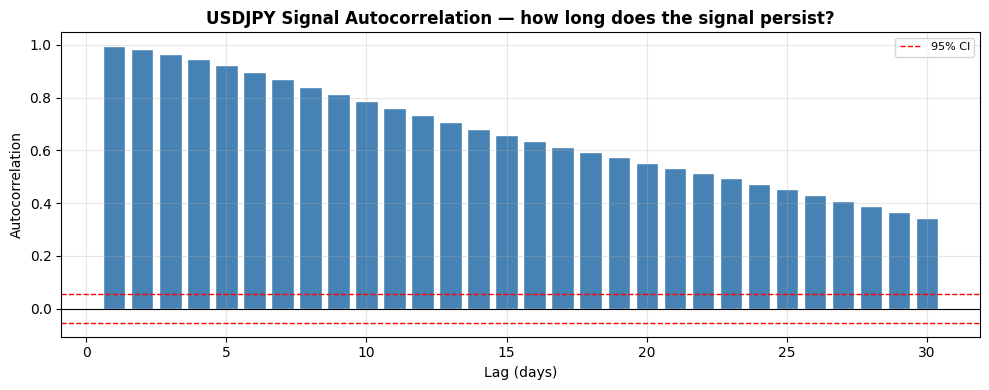

Lag-1 autocorr: 0.996 (>0.5 = persistent trend, near 0 = noisy)
Lag-5 autocorr: 0.922


In [38]:
# --- Signal autocorrelation: does the signal persist? ---
# A trend signal should have HIGH autocorrelation (it stays long for many days)
# A noise signal has near-zero autocorrelation (it flips every day)

sig_vals = sig_hypothesis[pair].dropna()
max_lag = 30
acf = [sig_vals.autocorr(lag=i) for i in range(1, max_lag + 1)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, max_lag + 1), acf, color="steelblue", edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.axhline( 1.96 / np.sqrt(len(sig_vals)), color="red", lw=1, linestyle="--", label="95% CI")
ax.axhline(-1.96 / np.sqrt(len(sig_vals)), color="red", lw=1, linestyle="--")
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Autocorrelation")
ax.set_title(f"{pair} Signal Autocorrelation — how long does the signal persist?", fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Lag-1 autocorr: {acf[0]:.3f} (>0.5 = persistent trend, near 0 = noisy)")
print(f"Lag-5 autocorr: {acf[4]:.3f}")

---
## 5 — Combining Signals: Blending Trend, Carry, and Mean Reversion

Using a single signal is fragile — it works in some regimes and breaks in others.
A **combined signal** averages multiple independent views, reducing the risk that
one regime kills the whole strategy.

**Three natural sources of FX edge:**

| Source | Signal type | When it works |
|---|---|---|
| **Trend** | `momentum` or `yield_trend` | Trending, momentum-driven markets |
| **Carry** | `carry_yield` | Stable, range-bound, low-vol environments |
| **Mean reversion** | `mean_reversion` or `rsi_signal` | Choppy, overshooting markets |

The simplest combination: **equal-weight average** of all three signals.

In [39]:
# Build each component signal across ALL 6 pairs
sig_trend = momentum(prices, lookback=20)
sig_carry = carry_yield(impl_yield, signal_type="sign")
sig_mr    = mean_reversion(prices, lookback=20, z_entry=1.5, z_exit=0.5)

# Combined: simple average
# If all three agree on direction, combined = ±1.0
# If two agree, one disagrees: combined = ±0.33
# If they all disagree: combined ≈ 0 (no trade)
sig_combined = (sig_trend + sig_carry + sig_mr) / 3.0

sizer = lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D")
cost  = FixedSpreadModel(slippage_bps=0.5)

r_trend    = Backtest(prices, sig_trend,    cost, sizer, freq="1D", name="Trend only",    pnl_mode="returns").run()
r_carry    = Backtest(prices, sig_carry,    cost, sizer, freq="1D", name="Carry only",    pnl_mode="returns").run()
r_mr       = Backtest(prices, sig_mr,       cost, sizer, freq="1D", name="Mean Rev only", pnl_mode="returns").run()
r_combined = Backtest(prices, sig_combined, cost, sizer, freq="1D", name="Combined (avg)",pnl_mode="returns").run()

compare(
    (r_trend.returns,    "Trend only"),
    (r_carry.returns,    "Carry only"),
    (r_mr.returns,       "Mean Rev only"),
    (r_combined.returns, "Combined (avg)"),
    freq="1D",
)

,Trend only,Carry only,Mean Rev only,Combined (avg)
Ann. Return,-1.36%,-2.49%,0.41%,-2.33%
Ann. Volatility,4.29%,4.24%,2.30%,3.44%
Sharpe Ratio,-0.32,-0.59,0.18,-0.68
Sortino Ratio,-0.52,-0.95,0.25,-1.06
Calmar Ratio,-0.10,-0.12,0.05,-0.13
Max Drawdown,-13.89%,-20.30%,-7.82%,-18.29%
Hit Rate,48.32%,47.47%,45.81%,47.93%
Profit Factor,0.95,0.91,1.03,0.90
Avg Win/Loss,1.02,1.01,1.22,0.97
VaR (95%),-0.46%,-0.45%,-0.24%,-0.37%


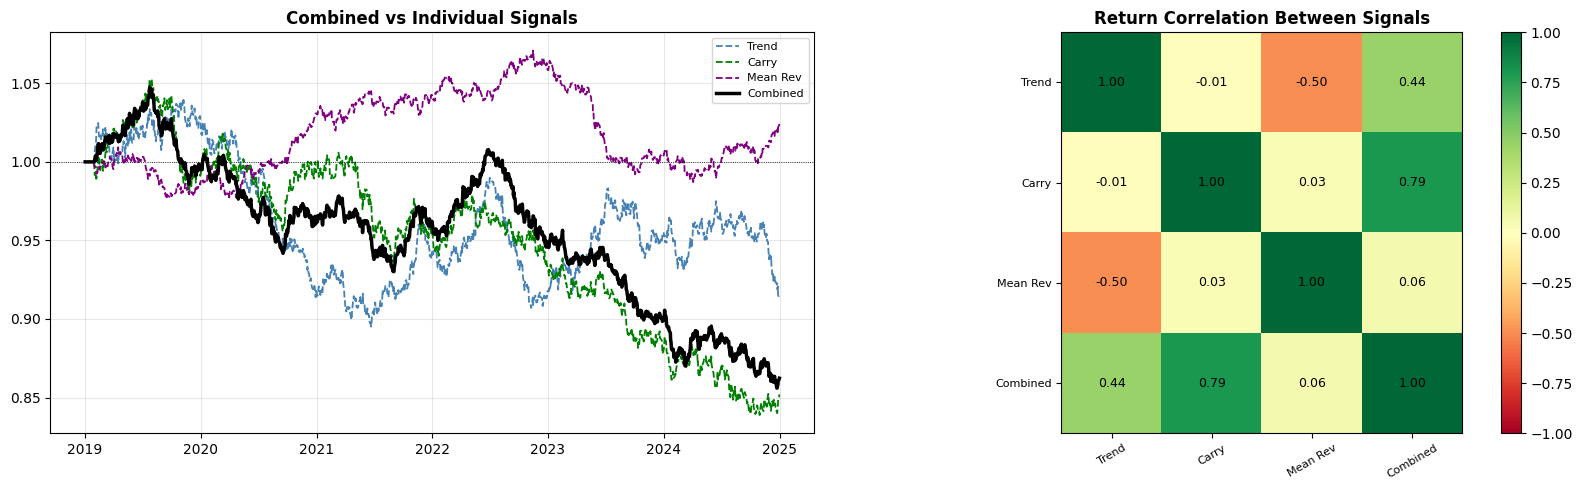

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Equity curves
for r, name, col in [
    (r_trend,    "Trend",     "steelblue"),
    (r_carry,    "Carry",     "green"),
    (r_mr,       "Mean Rev",  "purple"),
    (r_combined, "Combined",  "black"),
]:
    lw = 2.5 if name == "Combined" else 1.3
    axes[0].plot(r.equity_curve, lw=lw, color=col, label=name,
                 linestyle="-" if name == "Combined" else "--")
axes[0].axhline(1, color="black", lw=0.6, linestyle=":")
axes[0].set_title("Combined vs Individual Signals", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Correlation matrix of daily returns
ret_df = pd.DataFrame({
    "Trend":    r_trend.returns,
    "Carry":    r_carry.returns,
    "Mean Rev": r_mr.returns,
    "Combined": r_combined.returns,
}).dropna()

corr = ret_df.corr()
im = axes[1].imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(corr.columns, rotation=30, fontsize=8)
axes[1].set_yticks(range(4)); axes[1].set_yticklabels(corr.columns, fontsize=8)
axes[1].set_title("Return Correlation Between Signals", fontweight="bold")
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=axes[1], fraction=0.04)

plt.tight_layout(); plt.show()

**What to look for in the correlation matrix:**

- Low / negative correlation between components = good. It means they are exploiting
  *different* market dynamics. When one fails, the others may still work.
- High correlation (> 0.7) = they are essentially the same signal in disguise. No benefit to combining.
- The combined strategy's volatility should be **lower** than any individual component (diversification).


---
## 6 — Which Signal Works Best for Each Pair?

Different pairs have different structural characteristics:

- **G10 major pairs** (EURUSD, GBPUSD) tend to be more range-bound → mean reversion works better
- **Rate-differential pairs** (USDJPY) tend to trend with central bank divergence → carry/yield signals
- **EM pairs** (USDMXN, USDZAR) have persistent carry from high yield differentials → carry works well
- **Commodity currencies** (AUDUSD) follow commodity cycles → momentum on medium lookbacks

This cell runs all main signals on each pair individually and shows a heatmap of Sharpe ratios.

In [41]:
signal_defs = {
    "Momentum 20D":  momentum(prices, lookback=20),
    "MA Cross":      crossover(prices, fast=10, slow=50),
    "MACD":          macd_signal(prices),
    "Breakout 20D":  breakout(prices, lookback=20),
    "Mean Rev":      mean_reversion(prices, lookback=20),
    "RSI":           rsi_signal(prices, period=14),
    "Carry":         carry_yield(impl_yield, signal_type="sign"),
    "Yield Trend":   yield_trend(impl_yield, lookback=252),
}

sizer = lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D")
cost  = FixedSpreadModel(slippage_bps=0.5)

# Build a Sharpe matrix: rows = signals, columns = pairs
sharpe_matrix = pd.DataFrame(index=signal_defs.keys(), columns=PAIRS, dtype=float)

for sig_name, sig in signal_defs.items():
    for pair in PAIRS:
        r = Backtest(
            data       = prices[[pair]],
            signals    = sig[[pair]],
            cost_model = cost,
            sizer      = sizer,
            freq       = "1D",
            pnl_mode   = "returns",
        ).run()
        sharpe_matrix.loc[sig_name, pair] = sharpe(r.returns, freq="1D")

print("Sharpe Ratio by Signal × Pair:")
sharpe_matrix.round(2)

Sharpe Ratio by Signal × Pair:


,EURUSD,GBPUSD,USDJPY,AUDUSD,USDMXN,USDZAR
Momentum 20D,-0.14,0.04,0.32,-0.33,-0.56,-0.10
MA Cross,0.18,0.09,0.17,-0.29,-0.31,-0.14
MACD,0.10,0.35,0.09,-0.43,-0.64,-0.62
Breakout 20D,0.46,0.29,0.22,-0.60,0.08,-0.54
Mean Rev,-0.48,0.08,-0.37,0.38,-0.09,0.94
RSI,-0.03,-0.07,-0.15,0.71,0.11,0.15
Carry,-0.97,-0.16,-0.23,-0.06,-0.46,0.46
Yield Trend,0.64,0.05,0.42,-0.15,-0.35,0.67


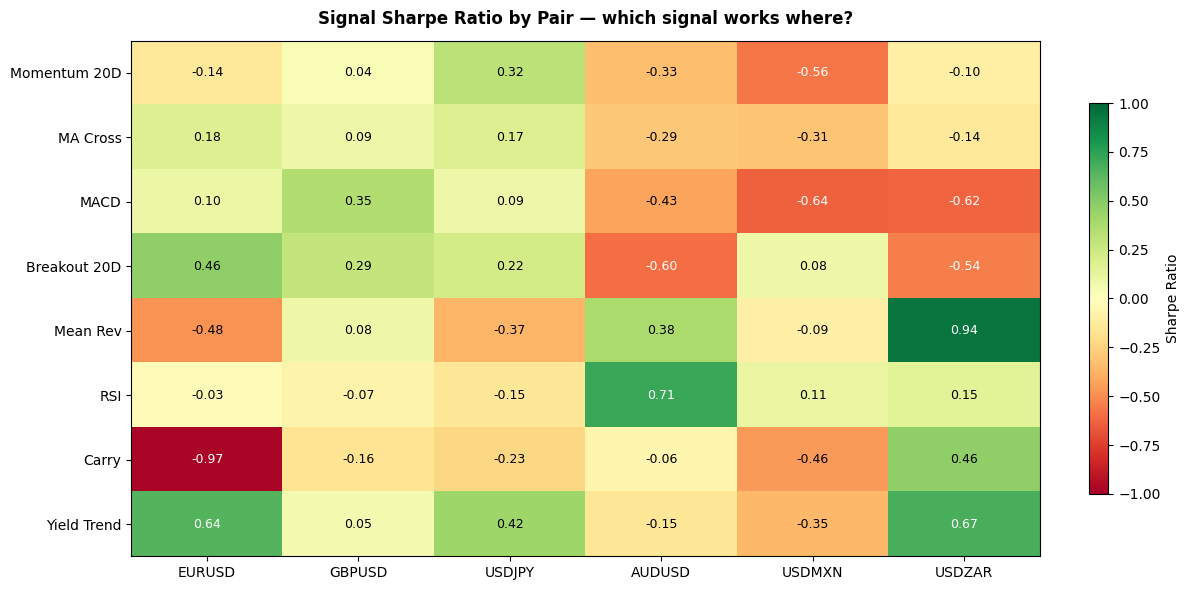

In [42]:
# Heatmap of Sharpe ratios
fig, ax = plt.subplots(figsize=(12, 6))
vals = sharpe_matrix.values.astype(float)
im = ax.imshow(vals, cmap="RdYlGn", vmin=-1.0, vmax=1.0, aspect="auto")

ax.set_xticks(range(len(PAIRS)))
ax.set_xticklabels(PAIRS, fontsize=10)
ax.set_yticks(range(len(signal_defs)))
ax.set_yticklabels(signal_defs.keys(), fontsize=10)
ax.set_title("Signal Sharpe Ratio by Pair — which signal works where?", fontweight="bold", pad=12)

for i in range(len(signal_defs)):
    for j in range(len(PAIRS)):
        v = vals[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                    color="black" if abs(v) < 0.5 else "white")

plt.colorbar(im, ax=ax, fraction=0.02, label="Sharpe Ratio")
plt.tight_layout(); plt.show()

**How to use this heatmap in practice:**

1. Find the **darkest green cells** — these are the best signal-pair combinations
2. For each pair in your portfolio, pick the signal that fits its structural characteristics
3. Avoid using the same signal family for every pair — that just concentrates one type of risk
4. **Green does not mean guaranteed** — always validate with walk-forward (Section 9)


---
## 7 — Adding Filters: Reduce Noise, Keep Edge

Raw signals fire on every day. Filters **suppress signals** in environments where they
are unlikely to work, improving the Sharpe ratio without changing the underlying theory.

### Available filters

| Filter | Logic | When to use |
|---|---|---|
| `vol_regime` | Suppress signal when realised vol is in the top X% | Prevent overtrading in chaotic, gap-prone markets |
| Manual regime | Only trade above/below a threshold | Event filters, calendar-based rules |

**Rule of thumb:** filters improve Sharpe only if the *suppressed* periods are genuinely bad
for the signal. Always compare filtered vs unfiltered to confirm it helps.

In [43]:
pair = "EURUSD"
sig_raw = momentum(prices[[pair]], lookback=20)

# vol_regime returns 1 when vol is below the 75th percentile, 0 otherwise
# Multiplying by the raw signal → zero out trades in high-vol periods
vr_filter    = vol_regime(prices[[pair]], lookback=20, high_vol_percentile=75)
sig_filtered = sig_raw * vr_filter

sizer = lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D")
cost  = FixedSpreadModel(slippage_bps=0.5)

r_raw = Backtest(prices[[pair]], sig_raw,      cost, sizer, freq="1D",
                 name="Raw momentum",      pnl_mode="returns").run()
r_flt = Backtest(prices[[pair]], sig_filtered, cost, sizer, freq="1D",
                 name="Vol-filtered",      pnl_mode="returns").run()

compare(
    (r_raw.returns, "Raw"),
    (r_flt.returns, "Vol-filtered"),
    freq="1D",
)

,Raw,Vol-filtered
Ann. Return,-1.49%,0.15%
Ann. Volatility,10.58%,9.70%
Sharpe Ratio,-0.14,0.02
Sortino Ratio,-0.22,0.02
Calmar Ratio,-0.06,0.01
Max Drawdown,-23.79%,-17.95%
Hit Rate,50.39%,47.99%
Profit Factor,0.98,1.00
Avg Win/Loss,0.96,1.09
VaR (95%),-1.11%,-1.07%


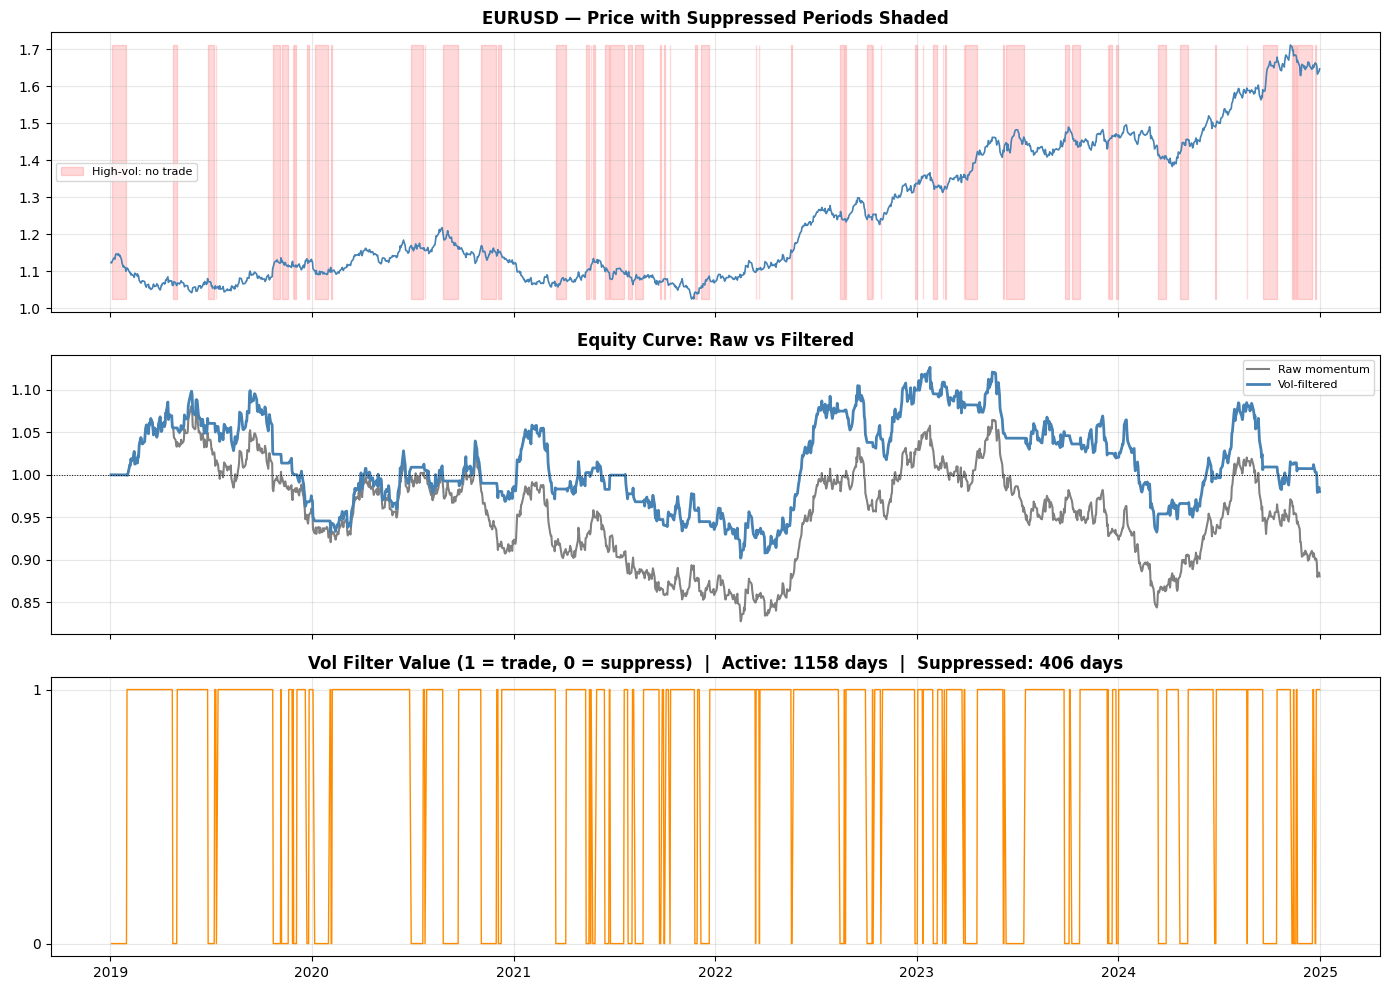

In [44]:
# Visualise: when does the filter suppress trading?
active_days    = (vr_filter[pair] == 1).sum()
suppressed_days = (vr_filter[pair] == 0).sum()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(prices[pair], lw=1.2, color="steelblue")
# Shade suppressed (high-vol) periods
suppressed = vr_filter[pair] == 0
axes[0].fill_between(prices.index, prices[pair].min(), prices[pair].max(),
                     where=suppressed, color="red", alpha=0.15, label="High-vol: no trade")
axes[0].set_title(f"{pair} — Price with Suppressed Periods Shaded", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].plot(r_raw.equity_curve, lw=1.5, color="gray",      label="Raw momentum")
axes[1].plot(r_flt.equity_curve, lw=2,   color="steelblue", label="Vol-filtered")
axes[1].axhline(1, color="black", lw=0.7, linestyle=":")
axes[1].set_title("Equity Curve: Raw vs Filtered", fontweight="bold")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].plot(vr_filter[pair], lw=1, color="darkorange")
axes[2].set_title(f"Vol Filter Value (1 = trade, 0 = suppress)  |  "
                  f"Active: {active_days} days  |  Suppressed: {suppressed_days} days",
                  fontweight="bold")
axes[2].set_yticks([0, 1]); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 8 — Conviction Sizing: Trade Bigger When More Confident

A binary +1/-1 signal treats a marginal view the same as a high-conviction view.
**Continuous signals** let the position sizer scale size with signal strength.

Two approaches:
1. **Z-score momentum** — signal magnitude reflects *how strong* the trend is
2. **Signal consensus** — how many independent signals agree? More agreement = bigger position

Both can be passed directly to `Backtest` — the vol-target sizer will scale by the magnitude.

In [45]:
# Approach 1: z-score signal (continuous strength)
sig_sign   = momentum(prices, lookback=20, signal_type="sign")    # binary ±1
sig_zscore = momentum(prices, lookback=20, signal_type="zscore")  # continuous

# Clip to ±3 to avoid extreme leverage from outlier z-scores
sig_zscore_clipped = sig_zscore.clip(-3, 3)

sizer = lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D")
cost  = FixedSpreadModel(slippage_bps=0.5)

r_binary = Backtest(prices, sig_sign,           cost, sizer, freq="1D",
                    name="Binary ±1",           pnl_mode="returns").run()
r_conv   = Backtest(prices, sig_zscore_clipped, cost, sizer, freq="1D",
                    name="Z-score (conviction)", pnl_mode="returns").run()

compare(
    (r_binary.returns, "Binary ±1"),
    (r_conv.returns,   "Z-score conviction"),
    freq="1D",
)

,Binary ±1,Z-score conviction
Ann. Return,-1.36%,-2.18%
Ann. Volatility,4.29%,4.18%
Sharpe Ratio,-0.32,-0.52
Sortino Ratio,-0.52,-0.81
Calmar Ratio,-0.10,-0.12
Max Drawdown,-13.89%,-18.17%
Hit Rate,48.32%,49.49%
Profit Factor,0.95,0.92
Avg Win/Loss,1.02,0.94
VaR (95%),-0.46%,-0.45%


In [46]:
# Approach 2: signal consensus — how many signals agree?
sig_mom   = np.sign(momentum(prices, lookback=20))
sig_cross = crossover(prices, fast=10, slow=50)
sig_carry = carry_yield(impl_yield, signal_type="sign")

# Count: +3 = all long, +1 = 2 long 1 short, 0 = split, -3 = all short
sig_consensus = sig_mom + sig_cross + sig_carry  # range: -3 to +3

r_consensus = Backtest(prices, sig_consensus, cost, sizer, freq="1D",
                       name="Consensus (3 signals)", pnl_mode="returns").run()

compare(
    (r_binary.returns,    "Binary (momentum only)"),
    (r_conv.returns,      "Z-score conviction"),
    (r_consensus.returns, "Consensus (3 signals)"),
    freq="1D",
)

,Binary (momentum only),Z-score conviction,Consensus (3 signals)
Ann. Return,-1.36%,-2.18%,-2.63%
Ann. Volatility,4.29%,4.18%,4.15%
Sharpe Ratio,-0.32,-0.52,-0.63
Sortino Ratio,-0.52,-0.81,-1.04
Calmar Ratio,-0.10,-0.12,-0.15
Max Drawdown,-13.89%,-18.17%,-17.99%
Hit Rate,48.32%,49.49%,48.45%
Profit Factor,0.95,0.92,0.90
Avg Win/Loss,1.02,0.94,0.96
VaR (95%),-0.46%,-0.45%,-0.43%


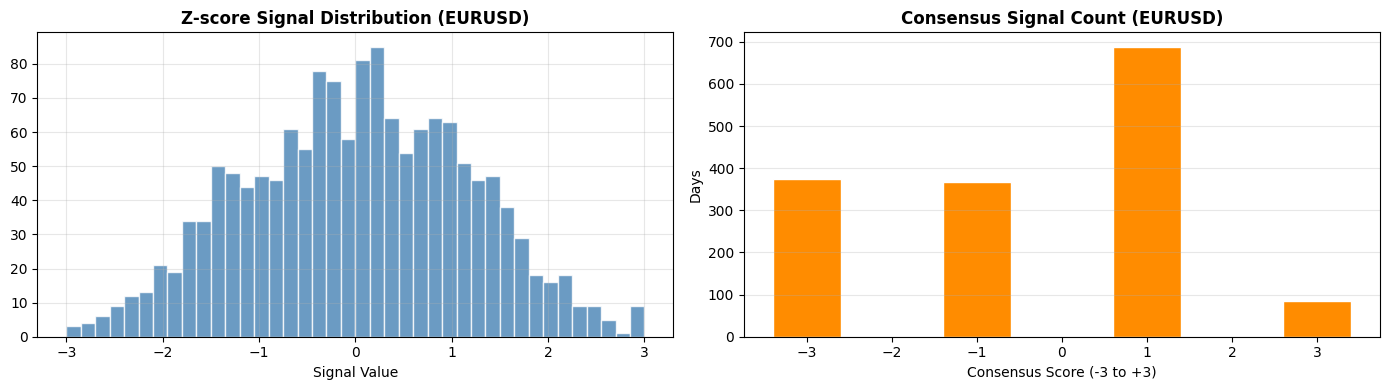

In [47]:
# Distribution of signal values: how often does consensus align?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sig_zscore_clipped["EURUSD"].dropna(), bins=40,
             color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Z-score Signal Distribution (EURUSD)", fontweight="bold")
axes[0].set_xlabel("Signal Value"); axes[0].grid(True, alpha=0.3)

counts = sig_consensus["EURUSD"].value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color="darkorange", edgecolor="white")
axes[1].set_title("Consensus Signal Count (EURUSD)", fontweight="bold")
axes[1].set_xlabel("Consensus Score (-3 to +3)")
axes[1].set_ylabel("Days")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

---
## 9 — Walk-Forward Reality Check: Does the Edge Survive Unseen Data?

**In-sample results are always better than live performance.** The backtest has seen
every data point it is tested on — it benefits from hindsight even if you haven't
explicitly fitted parameters.

**Walk-forward testing** enforces a strict train/test discipline:

```
|-- Train (1yr) --|-- Test (3mo) --|
                  |-- Train (1yr) --|-- Test (3mo) --|
                                   |-- Train (1yr) --|-- Test (3mo) --|
```

The signal is calibrated on the **train** window only. Performance is measured on the
**test** window (data the signal has *never seen*). All test windows are stitched together.

A strategy is only worth trading if the walk-forward Sharpe is meaningfully positive.

In [48]:
# Walk-forward on the combined signal from Section 5
sig_combined = (
    momentum(prices, lookback=20) +
    carry_yield(impl_yield, signal_type="sign") +
    mean_reversion(prices, lookback=20)
) / 3.0

sizer = lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D")
cost  = FixedSpreadModel(slippage_bps=0.5)

# In-sample baseline
r_is = Backtest(prices, sig_combined, cost, sizer,
                freq="1D", name="In-Sample", pnl_mode="returns").run()

# Walk-forward (252 day train, 63 day test = 1yr/3mo rolling)
def wf_signal_fn(train_prices, test_prices):
    combined = pd.concat([train_prices, test_prices])
    sig = (
        momentum(combined, lookback=20) +
        carry_yield(impl_yield.loc[combined.index], signal_type="sign") +
        mean_reversion(combined, lookback=20)
    ) / 3.0
    return sig.loc[test_prices.index]

r_oos = Backtest(prices, sig_combined, cost, sizer,
                 freq="1D", name="Walk-Forward OOS", pnl_mode="returns",
).walk_forward(train_periods=252, test_periods=63, signal_fn=wf_signal_fn)

compare(
    (r_is.returns,  "In-Sample"),
    (r_oos.returns, "Walk-Forward OOS"),
    freq="1D",
)

,In-Sample,Walk-Forward OOS
Ann. Return,-2.33%,-2.54%
Ann. Volatility,3.44%,2.81%
Sharpe Ratio,-0.68,-0.90
Sortino Ratio,-1.06,-1.14
Calmar Ratio,-0.13,-0.21
Max Drawdown,-18.29%,-12.34%
Hit Rate,47.93%,46.90%
Profit Factor,0.90,0.84
Avg Win/Loss,0.97,0.95
VaR (95%),-0.37%,-0.32%


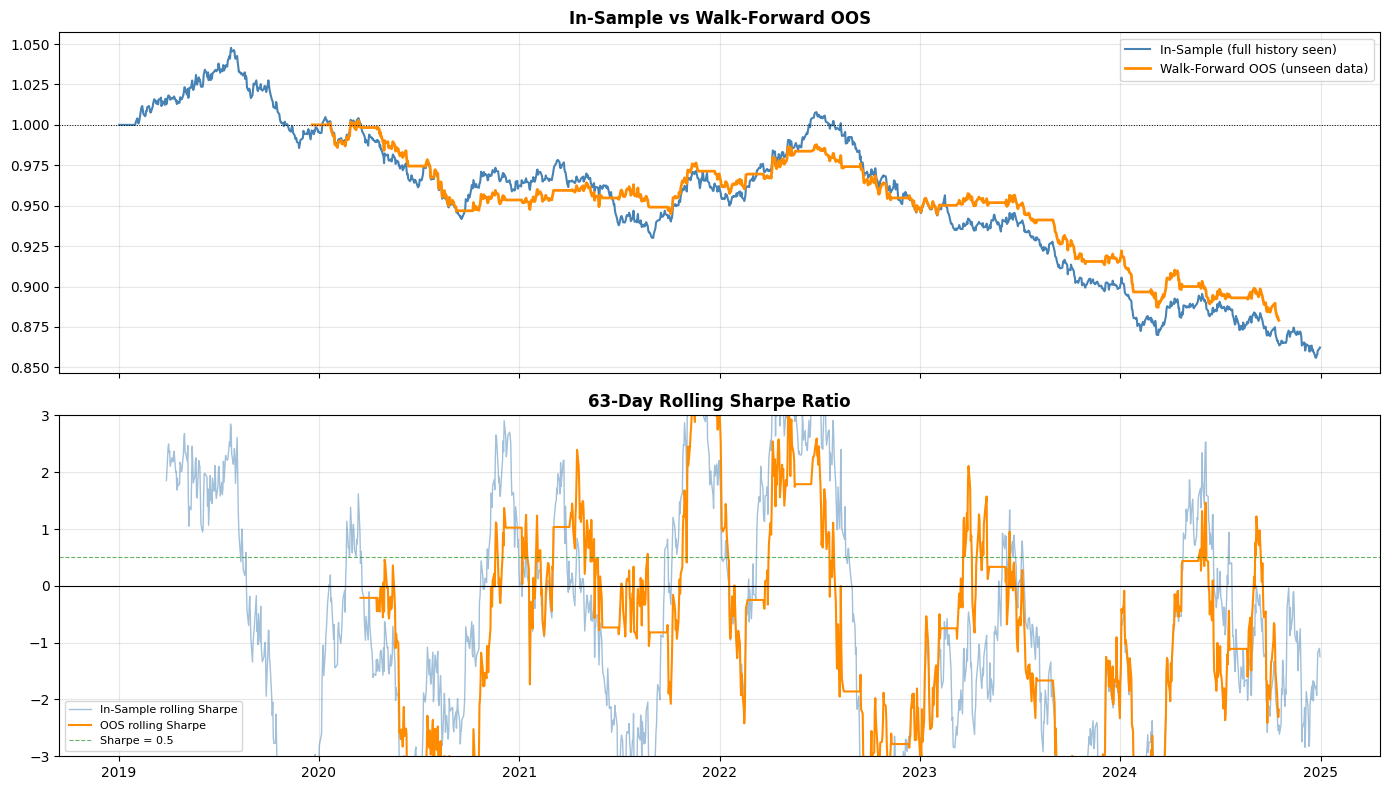

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(r_is.equity_curve,  lw=1.5, color="steelblue",  label="In-Sample (full history seen)")
axes[0].plot(r_oos.equity_curve, lw=2,   color="darkorange", label="Walk-Forward OOS (unseen data)")
axes[0].axhline(1, color="black", lw=0.7, linestyle=":")
axes[0].set_title("In-Sample vs Walk-Forward OOS", fontweight="bold")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Rolling 63-day Sharpe to show consistency over time
def rolling_sharpe(returns, window=63):
    return returns.rolling(window).apply(
        lambda x: x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan
    )

rs_is  = rolling_sharpe(r_is.returns.dropna())
rs_oos = rolling_sharpe(r_oos.returns.dropna())

axes[1].plot(rs_is,  lw=1, color="steelblue",  alpha=0.5, label="In-Sample rolling Sharpe")
axes[1].plot(rs_oos, lw=1.5, color="darkorange", label="OOS rolling Sharpe")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axhline(0.5, color="green", lw=0.8, linestyle="--", alpha=0.6, label="Sharpe = 0.5")
axes[1].set_title("63-Day Rolling Sharpe Ratio", fontweight="bold")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-3, 3)

plt.tight_layout(); plt.show()

**Decision rule:**

| OOS Sharpe | Action |
|---|---|
| > 0.5 | Strong — proceed to live trading with appropriate sizing |
| 0.2 – 0.5 | Marginal — paper trade, continue monitoring |
| 0 – 0.2 | Weak — not worth deploying capital yet |
| < 0 | The edge does not exist out-of-sample — do not trade |

If in-sample Sharpe >> OOS Sharpe, you likely **overfit** — too many parameters, too
short a history, or a signal that was tuned on the same data it was tested on.


---
## 10 — Final Trade Decision: Go / No-Go Framework

This section synthesises everything into a single decision scorecard.
For each pair, score it across five dimensions. Trade only when enough criteria are met.

| Criterion | How to check | Threshold |
|---|---|---|
| **Signal direction** | What does the combined signal say today? | Must be non-zero |
| **Signal strength** | What is the z-score / consensus score? | > 0.5 abs. |
| **Vol regime** | Are we in a "tradeable" vol environment? | Filter = 1 (not suppressed) |
| **OOS Sharpe** | Did the signal survive walk-forward? | > 0.3 |
| **Annual consistency** | How many of the last 3 years were profitable? | >= 2 of 3 |

A pair must pass **4 of 5** criteria to be included in today's book.

In [50]:
# Build a decision scorecard for the last available date (most recent signal)
today = prices.index[-1]
lookback_years = 3

# Re-run all components on the full dataset
sig_trend  = momentum(prices, lookback=20)
sig_carry_ = carry_yield(impl_yield, signal_type="sign")
sig_mr_    = mean_reversion(prices, lookback=20)
sig_comb   = (sig_trend + sig_carry_ + sig_mr_) / 3.0
vr         = vol_regime(prices, lookback=20, high_vol_percentile=75)

sizer = lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D")
cost  = FixedSpreadModel(slippage_bps=0.5)

scorecard_rows = []

for pair in PAIRS:
    # 1. Signal direction today
    sig_today = sig_comb.loc[today, pair]

    # 2. Signal strength (abs value)
    sig_strength = abs(sig_today)

    # 3. Vol regime (1 = tradeable)
    vr_today = vr.loc[today, pair]

    # 4. OOS Sharpe (from walk-forward on this pair's momentum)
    r_pair = Backtest(prices[[pair]], sig_comb[[pair]], cost, sizer,
                      freq="1D", pnl_mode="returns").run()
    oos_sharpe = sharpe(r_pair.returns, freq="1D")

    # 5. Annual consistency over last N years
    ann = r_pair.returns.resample("A").sum()
    recent_ann = ann.iloc[-lookback_years:]
    years_positive = (recent_ann > 0).sum()

    # Score (each criterion = 1 point)
    score = sum([
        sig_today != 0,
        sig_strength > 0.25,
        vr_today == 1,
        oos_sharpe > 0.3,
        years_positive >= 2,
    ])

    direction = "LONG" if sig_today > 0 else ("SHORT" if sig_today < 0 else "FLAT")

    scorecard_rows.append({
        "Pair":          pair,
        "Direction":     direction,
        "Strength":      round(sig_strength, 3),
        "Vol OK":        "Yes" if vr_today == 1 else "No",
        "OOS Sharpe":    round(oos_sharpe, 2),
        "Yrs Positive":  f"{years_positive}/{lookback_years}",
        "Score (5)":     score,
        "Trade?":        "YES" if score >= 4 else "no",
    })

scorecard = pd.DataFrame(scorecard_rows).set_index("Pair")
print(f"Decision Scorecard — {today.date()}")
scorecard

Decision Scorecard — 2024-12-31


,Direction,Strength,Vol OK,OOS Sharpe,Yrs Positive,Score (5),Trade?
Pair,,,,,,,
EURUSD,SHORT,0.667,Yes,-1.15,0/3,3,no
GBPUSD,SHORT,0.667,Yes,-0.06,1/3,3,no
USDJPY,LONG,0.667,Yes,-0.01,1/3,3,no
AUDUSD,FLAT,0.000,No,-0.23,0/3,0,no
USDMXN,LONG,0.667,Yes,-0.85,0/3,3,no
USDZAR,FLAT,0.000,Yes,0.61,3/3,3,no


In [51]:
# Summary: which pairs to trade today and in which direction
trades = scorecard[scorecard["Trade?"] == "YES"]
print(f"\nPairs to trade today ({len(trades)} of {len(PAIRS)}):")
for pair, row in trades.iterrows():
    print(f"  {pair:8s}  {row['Direction']:5s}  strength={row['Strength']:.2f}  OOS Sharpe={row['OOS Sharpe']:.2f}")

if len(trades) == 0:
    print("  None — no pairs pass the minimum criteria today.")


Pairs to trade today (0 of 6):
  None — no pairs pass the minimum criteria today.


---
## Summary: The Decision Workflow

```
1. Start with a theory
   "USDJPY trends with US-JP rate divergence"

2. Translate to a signal
   yield_trend(impl_yield, pair='USDJPY')

3. Diagnose the signal
   - Annual breakdown: is the edge consistent?
   - Regime analysis: does it work in high/low vol?
   - Autocorrelation: does the signal persist?

4. Combine for robustness
   sig = (trend + carry + mean_reversion) / 3

5. Add filters
   sig = sig * vol_regime(prices)  # suppress in chaotic markets

6. Validate out-of-sample
   walk_forward(train=252, test=63)

7. Score each pair daily
   Trade only pairs that pass >= 4 of 5 criteria

8. Execute with build_trade_table()
   Compute delta vs yesterday's position, attach reference rates
```

**The framework does not tell you *what* to trade — it tells you *whether* your theory
has a statistically testable edge and how to act on it consistently.**
